#### APIs as a data source: Batch vs Streaming Approaches

APIs are a major source of data ingestion. Depending on how APIs provide data, they can be used in both batch and streaming workflows.

#### 1. APIs for batch extraction
Some APIs return large datasets at once. This data is often fetched on a schedule or as apart of an ETL process.


In [6]:
import requests
import truststore

truststore.inject_into_ssl()   # patches ssl to use Windows cert store

url = "https://api.github.com/repos/DataTalksClub/data-engineering-zoomcamp/events"
response = requests.get(url, timeout=30)
response.raise_for_status()

response.json()

[{'id': '10654390346',
  'type': 'WatchEvent',
  'actor': {'id': 122197620,
   'login': 'cynthiaumwali',
   'display_login': 'cynthiaumwali',
   'gravatar_id': '',
   'url': 'https://api.github.com/users/cynthiaumwali',
   'avatar_url': 'https://avatars.githubusercontent.com/u/122197620?'},
  'repo': {'id': 419661684,
   'name': 'DataTalksClub/data-engineering-zoomcamp',
   'url': 'https://api.github.com/repos/DataTalksClub/data-engineering-zoomcamp'},
  'payload': {'action': 'started'},
  'public': True,
  'created_at': '2026-06-13T17:05:12Z',
  'org': {'id': 72699292,
   'login': 'DataTalksClub',
   'gravatar_id': '',
   'url': 'https://api.github.com/orgs/DataTalksClub',
   'avatar_url': 'https://avatars.githubusercontent.com/u/72699292?'}},
 {'id': '10653981267',
  'type': 'WatchEvent',
  'actor': {'id': 102401691,
   'login': 'amzedkhan',
   'display_login': 'amzedkhan',
   'gravatar_id': '',
   'url': 'https://api.github.com/users/amzedkhan',
   'avatar_url': 'https://avatars.git

Common challenges with API batch processing:

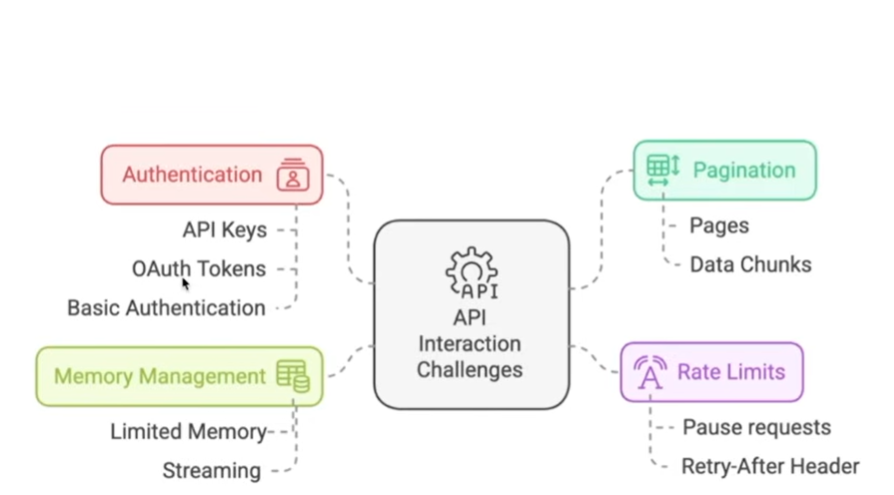

- First challenge is authentication
- We dont get all data at once when we use get method to fetch API data and need to use concept of 'Pagination' to access older data.
- Rate Limits- Problems related to too many request that the api server can handle which is frequent in large dtaasets like Google ANlytics data.
- Also finally there could be memory issues, meaning the api returns so much data that the computer cannot handle gracefully or process at once.

Solution:
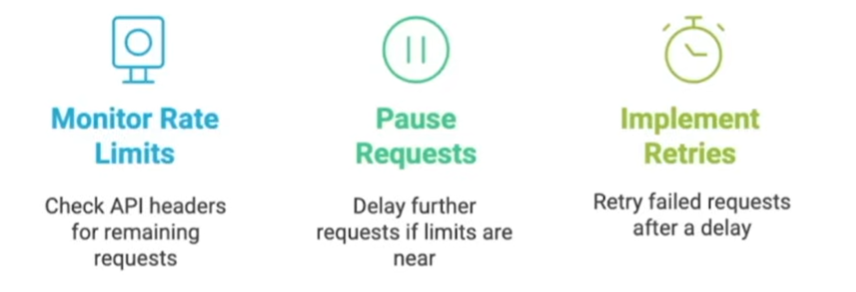

In [7]:
url = "https://api.github.com/rate_limit"

print(requests.get(url).json()) # See the rate limit for the GitHub API
remaining_requests = requests.get(url).json()["rate"]["remaining"] # Get the number of remaining requests
print(f"Remaining requests: {remaining_requests}") # Print the number of remaining requests




{'resources': {'code_search': {'limit': 60, 'remaining': 58, 'reset': 1781372919, 'used': 2, 'resource': 'code_search'}, 'core': {'limit': 60, 'remaining': 58, 'reset': 1781372919, 'used': 2, 'resource': 'core'}, 'graphql': {'limit': 0, 'remaining': 0, 'reset': 1781374017, 'used': 0, 'resource': 'graphql'}, 'integration_manifest': {'limit': 5000, 'remaining': 5000, 'reset': 1781374017, 'used': 0, 'resource': 'integration_manifest'}, 'search': {'limit': 10, 'remaining': 10, 'reset': 1781370477, 'used': 0, 'resource': 'search'}}, 'rate': {'limit': 60, 'remaining': 58, 'reset': 1781372919, 'used': 2, 'resource': 'core'}}
Remaining requests: 58


In [8]:
# Handle rate Limits
import time

url = "https://api.github.com/rate_limit"

remaining_requests = requests.get(url).json()["rate"]["remaining"] # Get the number of remaining requests

if remaining_requests == 0:
    time.sleep(30) # Sleep for 60 seconds if there are no remaining requests

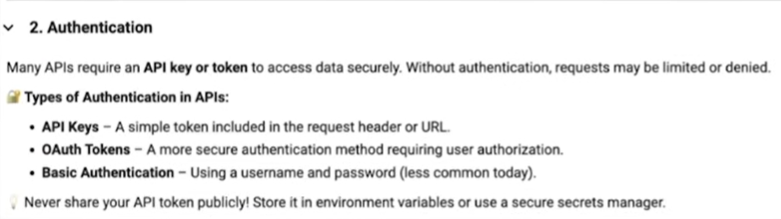

In [9]:
url = "https://api.github.com/user"
requests.get(url).json() # This will raise an error because we are not authenticated

{'message': 'Requires authentication',
 'documentation_url': 'https://docs.github.com/rest',
 'status': '401'}

Note that I have generated a classic personal access token on github developer section (expiring in 60days from 13-06-20256) which I want to use in vs code in my current script session to access the above github api. Though doable but its not a good practice even for learning purpose to paste the token in the script.
Better approach for your current VS Code script/notebook session:

Set the token once as a Windows User environment variable, then restart VS Code.

This makes the same token available to:

Integrated terminal
Notebook kernel
Python scripts in that VS Code session
Steps (PowerShell):

Set token permanently for your user:
```Powershell
[Environment]::SetEnvironmentVariable("GITHUB_TOKEN","YOUR_NEW_TOKEN_HERE","User")
```

Close all VS Code windows completely.

Reopen VS Code and your notebook.

Verify in terminal:
```Powershell
echo $env:GITHUB_TOKEN
(or safer)
if ($env:GITHUB_TOKEN) { "Token present" } else { "Missing" }
```

Verify in notebook:
```Python
import os
print("Token loaded:", bool(os.getenv("GITHUB_TOKEN")))
```
Important:

Because your token was shown in terminal earlier, revoke it in GitHub and create a new token.
After rotation, run step 1 again with the new token.
Do not paste token into notebook cells or markdown.

In [1]:
import os
print("Token loaded:", bool(os.getenv("GITHUB_TOKEN")))

Token loaded: True


In [4]:
import requests
import truststore

truststore.inject_into_ssl()   # patches ssl to use Windows cert store

API_TOKEN = os.getenv("GITHUB_TOKEN") # Get the API token from the windows environment variable
headers = {"Authorization": f"Bearer {API_TOKEN}"} # Create the headers for authentication

url = "https://api.github.com/user"
requests.get(url, headers=headers).json() # This will return the authenticated user's information




{'login': 'ganeshchandra015',
 'id': 115874538,
 'node_id': 'U_kgDOBuga6g',
 'avatar_url': 'https://avatars.githubusercontent.com/u/115874538?v=4',
 'gravatar_id': '',
 'url': 'https://api.github.com/users/ganeshchandra015',
 'html_url': 'https://github.com/ganeshchandra015',
 'followers_url': 'https://api.github.com/users/ganeshchandra015/followers',
 'following_url': 'https://api.github.com/users/ganeshchandra015/following{/other_user}',
 'gists_url': 'https://api.github.com/users/ganeshchandra015/gists{/gist_id}',
 'starred_url': 'https://api.github.com/users/ganeshchandra015/starred{/owner}{/repo}',
 'subscriptions_url': 'https://api.github.com/users/ganeshchandra015/subscriptions',
 'organizations_url': 'https://api.github.com/users/ganeshchandra015/orgs',
 'repos_url': 'https://api.github.com/users/ganeshchandra015/repos',
 'events_url': 'https://api.github.com/users/ganeshchandra015/events{/privacy}',
 'received_events_url': 'https://api.github.com/users/ganeshchandra015/receive

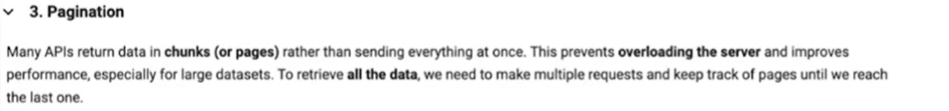

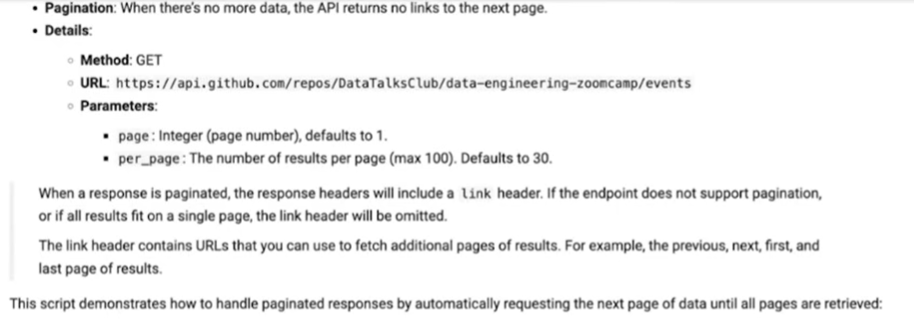

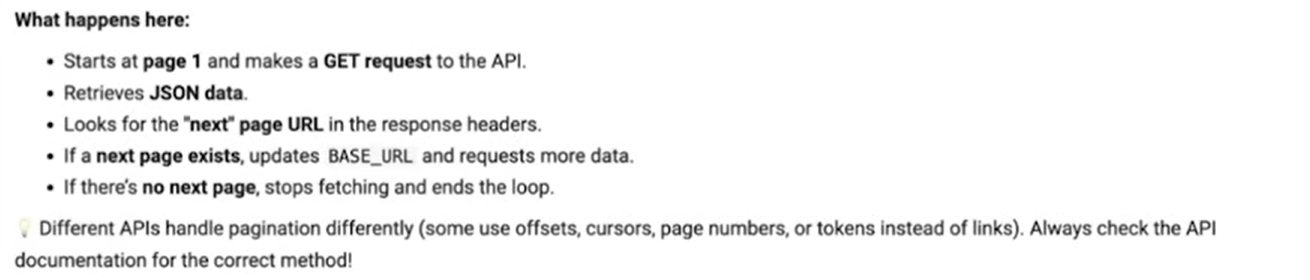

In [5]:
url = "https://api.github.com/repos/DataTalksClub/data-engineering-zoomcamp/events"

response = requests.get(url)
response.headers['Link'] # This will show the Link header which contains the URL for the next page of results

# Note that the link of the next page in results is different from the original URL, it contains a query parameter 'page' which indicates the page number of results. 
# This is how we can navigate through the paginated results by changing the page number in the URL.

'<https://api.github.com/repositories/419661684/events?page=2>; rel="next", <https://api.github.com/repositories/419661684/events?page=10>; rel="last"'

In [6]:
# We will use the 'requests' library to parse the Link header for us. The 'links' attribute of the response object will contain a dictionary of the parsed links.
#  We will identify the last page of results by looking for the 'rel' attribute with the value 'last' in the Link header.
# This will help if we want to create a loop to iterate through all the pages of results until we reach the last page.
response.links # This will show the parsed Link header as a dictionary
# Explanation of the Link header:
# The Link header is used for pagination in the GitHub API. It contains URLs for the next, previous, first, and last pages of results. The 'rel' attribute indicates the relation type (e.g., 'next', 'prev', 'first', 'last').
# For example, if the Link header contains:
# <https://api.github.com/repositories/123456/events?page=2>; rel="next", <https://api.github.com/repositories/123456/events?page=5>; rel="last"
# This means that the next page of results can be accessed at https://api.github.com/repositories/123456/events?page=2 and the last page of results can be accessed at https://api.github.com/repositories/123456/events?page=5.


{'next': {'url': 'https://api.github.com/repositories/419661684/events?page=2',
  'rel': 'next'},
 'last': {'url': 'https://api.github.com/repositories/419661684/events?page=10',
  'rel': 'last'}}

In [9]:
# Cross verify if there are no more pages of results by accessing the last page of results directly using the URL from the Link header
last_url = "https://api.github.com/repositories/419661684/events?page=10"
response.headers['Link'] # This will show the Link header which contains the URL for the next page of results

# As evident from the result the Link header shows page=9 as the next page of results, which means that there are no more pages of results after page=10. 
# This confirms that we have reached the last page of results.

'<https://api.github.com/repositories/419661684/events?page=9>; rel="prev", <https://api.github.com/repositories/419661684/events?page=1>; rel="first"'

In [10]:
# Lets now build a loop to iterate through all the pages of results until we reach the last page.
url = "https://api.github.com/repos/DataTalksClub/data-engineering-zoomcamp/events"

while True:    
    response = requests.get(url)
    data = response.json() # Get the data from the response
    print(f"Number of events in this page: {len(data)}") # Print the number of events in this page

    if 'next' in response.links:
        url = response.links['next']['url'] # Update the URL to the next page of results
    else:
        break # If there is no next page of results, break the loop

# Note that each api setup is different, so the way to navigate through paginated results may vary. 
# Different apis handle pagination differently, some use cursors, some use offsets, and some use page numbers or tokens instead of links. 
# Always refer to the API documentation for details on how to handle pagination.
# To check the api documentation of any endpoint, you can use the 'docs_url' attribute of the response object which will provide the URL to the API documentation for that endpoint.
# response.json()[0].keys() 
# This will show the keys of the first event in the results, which can help us understand the structure of the data and how to extract the information we need.

Number of events in this page: 30
Number of events in this page: 30
Number of events in this page: 30
Number of events in this page: 30
Number of events in this page: 30
Number of events in this page: 30
Number of events in this page: 30
Number of events in this page: 30
Number of events in this page: 30
Number of events in this page: 30


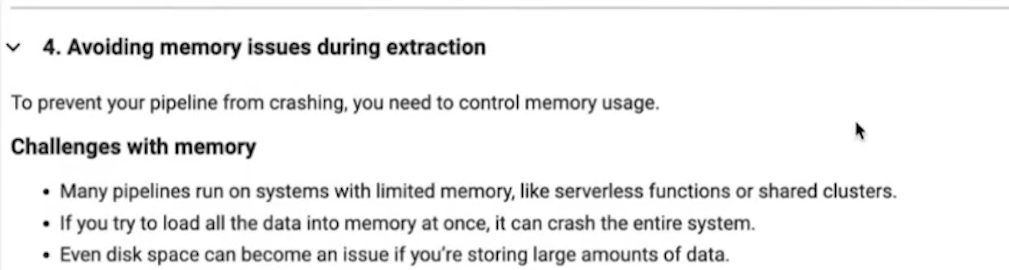

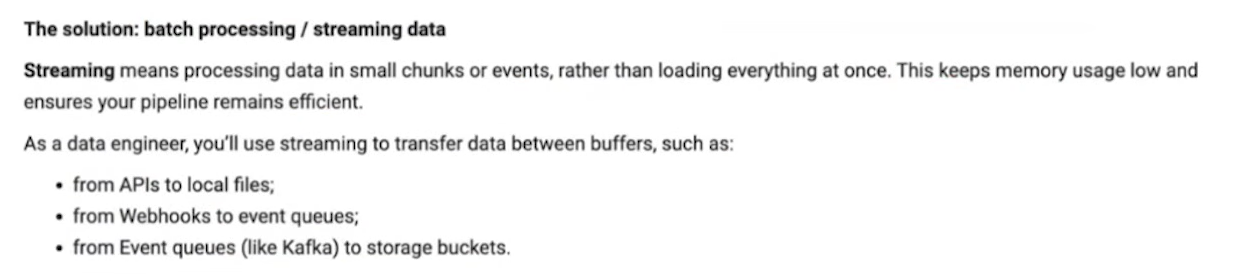

In [12]:
# To avoid memory issues when dealing with large datasets, we can process the data in chunks instead of loading all the data into memory at once.
# The structure of the method to process data in chunks will depend on the specific use case and the structure of the data, 
# but generally it involves processing each page of results as it is retrieved, rather than storing all the results in a list or dataframe before processing.
# Processing here means extracting the relevant information from the data and storing it in a structured format, 
# such as a dataframe or a database, for further analysis or processing.
# Once you read the data from the API, the data is stored in a list of dictionaries, where each dictionary represents an event. 
# An event is a JSON object that contains information about a specific event, such as the type of event, the user who triggered the event, and the repository where the event occurred.
# You can then convert this list of dictionaries into a pandas dataframe for further analysis or processing.

def events_getter(): # This function will be a generator that yields one event at a time from the API
    url = "https://api.github.com/repos/DataTalksClub/data-engineering-zoomcamp/events"

    while True:    
        response = requests.get(url)
        data = response.json() # Get the data from the response
        yield from data # Yield each event in the data, meaning that the function will return one event at a time instead of the whole list of events. Yield is a more memory efficient way to return data from a function, especially when dealing with large datasets.

        if 'next' in response.links:
            url = response.links['next']['url'] # Update the URL to the next page of results
        else:
            break # If there is no next page of results, break the loop

In [13]:
events_pages = events_getter() # Create a generator object that will yield one event at a time from the API

for event in events_pages: # Iterate through the generator object to get one event at a time
    print(event) # Print the event
    # You can also process the event here, such as extracting relevant information and storing it in a structured format for further analysis or processing.

{'id': '10664114272', 'type': 'WatchEvent', 'actor': {'id': 25285360, 'login': 'Babalsaab', 'display_login': 'Babalsaab', 'gravatar_id': '', 'url': 'https://api.github.com/users/Babalsaab', 'avatar_url': 'https://avatars.githubusercontent.com/u/25285360?'}, 'repo': {'id': 419661684, 'name': 'DataTalksClub/data-engineering-zoomcamp', 'url': 'https://api.github.com/repos/DataTalksClub/data-engineering-zoomcamp'}, 'payload': {'action': 'started'}, 'public': True, 'created_at': '2026-06-14T07:00:52Z', 'org': {'id': 72699292, 'login': 'DataTalksClub', 'gravatar_id': '', 'url': 'https://api.github.com/orgs/DataTalksClub', 'avatar_url': 'https://avatars.githubusercontent.com/u/72699292?'}}
{'id': '10663789731', 'type': 'WatchEvent', 'actor': {'id': 101790827, 'login': 'Cautious-moth', 'display_login': 'Cautious-moth', 'gravatar_id': '', 'url': 'https://api.github.com/users/Cautious-moth', 'avatar_url': 'https://avatars.githubusercontent.com/u/101790827?'}, 'repo': {'id': 419661684, 'name': 'D

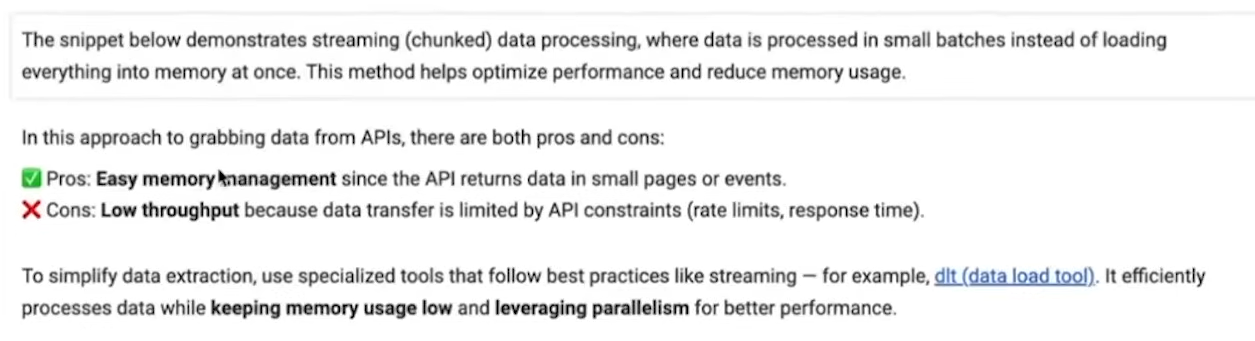

------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------

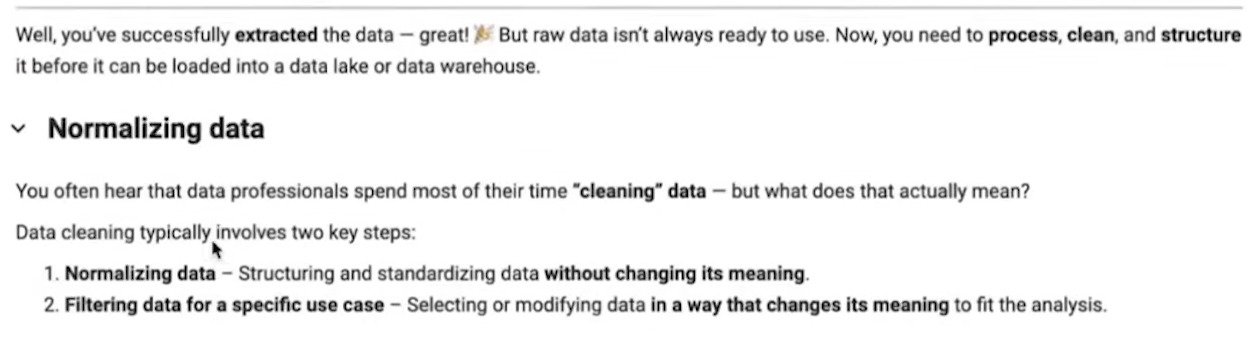

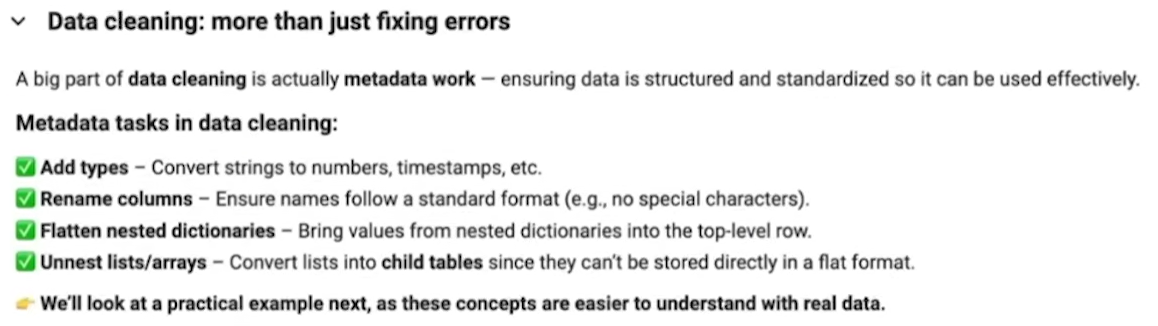

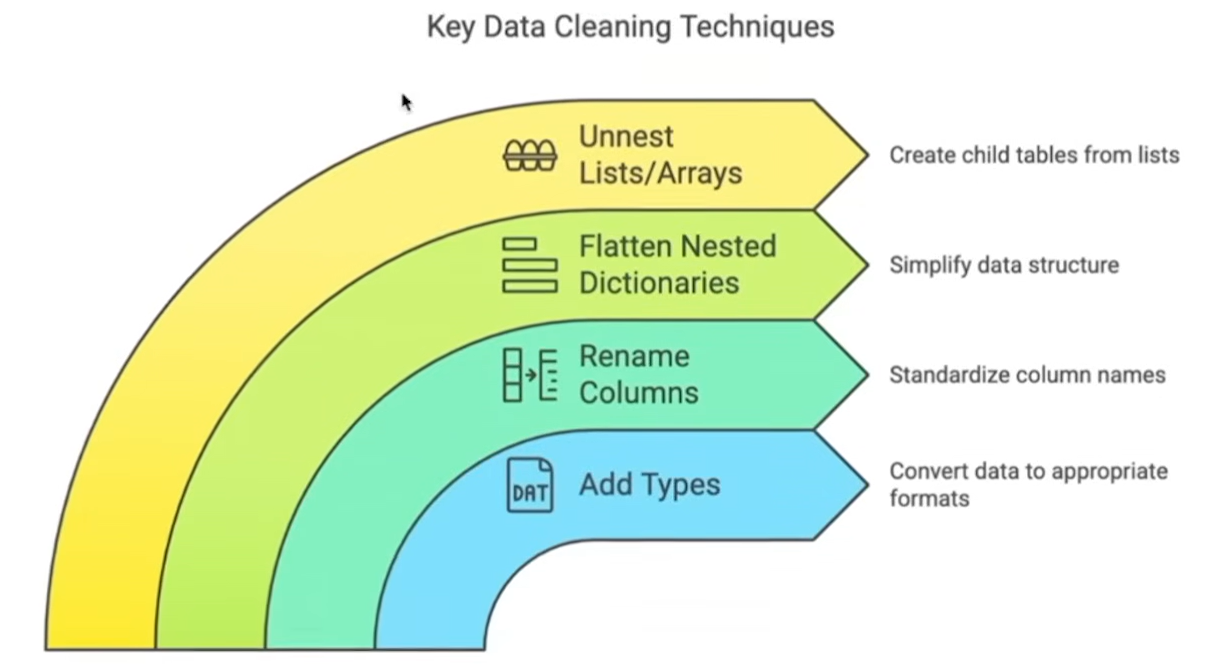

In [ ]:
# Lets look at a sample record from the API to understand the structure of the data and how to extract the information we need.
#  Normalizing Data means converting the nested JSON data into a flat table format, such as a pandas dataframe, 
# where each row represents an event and each column represents a specific attribute of the event.
# This is useful for further analysis or processing of the data, 
# as it allows us to easily manipulate and analyze the data using pandas or other data analysis libraries.
import json
events_pages = events_getter() # Create a generator object that will yield one event at a time from the API
event = next(events_pages) # Get the next event from the generator object (Since this gives next event item that is why we are re-calling the
                            # generator object, as it will give the first event in the first page of results)
print(json.dumps(event, indent=4))  # event is a dict, so use json.dumps(...) for better formatting of the output ,
# json.dumps is used to convert a Python object into a JSON string, and the 'indent' parameter is used to specify the number of spaces to use for indentation in the output JSON string, which makes it easier to read.
# event in above is python dict, so we can use json.dumps to convert it into a JSON string for better formatting of the output.
# If it would have been only rsponse which is of type requests.models.Response is a Python object that represents the response from an HTTP request made using the 'requests' library, 
# then we would have used response.json() to get the JSON data from the response and then used json.dumps to format it for better readability.

{
    "id": "10665942558",
    "type": "WatchEvent",
    "actor": {
        "id": 43399247,
        "login": "ogambamaria",
        "display_login": "ogambamaria",
        "gravatar_id": "",
        "url": "https://api.github.com/users/ogambamaria",
        "avatar_url": "https://avatars.githubusercontent.com/u/43399247?"
    },
    "repo": {
        "id": 419661684,
        "name": "DataTalksClub/data-engineering-zoomcamp",
        "url": "https://api.github.com/repos/DataTalksClub/data-engineering-zoomcamp"
    },
    "payload": {
        "action": "started"
    },
    "public": true,
    "created_at": "2026-06-14T09:24:45Z",
    "org": {
        "id": 72699292,
        "login": "DataTalksClub",
        "gravatar_id": "",
        "url": "https://api.github.com/orgs/DataTalksClub",
        "avatar_url": "https://avatars.githubusercontent.com/u/72699292?"
    }
}


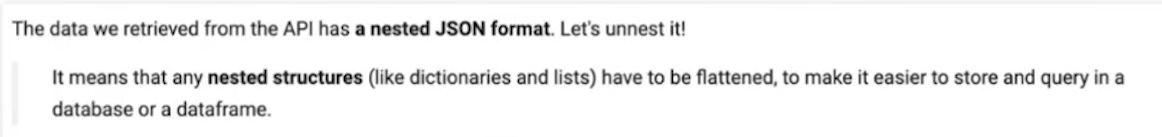

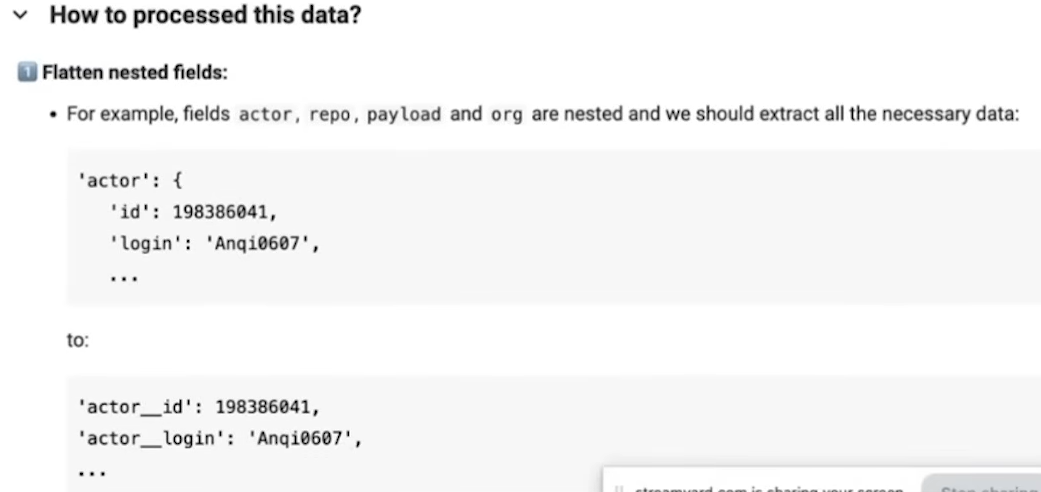

In [31]:
# Lets define a function now that takes in a raw event from the API and extracts the relevant information and returns it in a structured format, such as a dictionary or a pandas dataframe.

def process_event(event): # This function will take in a raw event from the API and extract the relevant information and return it in a structured format, such as a dictionary or a pandas dataframe.
    result = {} # Create an empty dictionary to store the extracted information

    result['id'] = event['id'] # Extract the 'id' of the event and store it in the result dictionary
    result['type'] = event['type'] # Extract the 'type' of the event and store it in the result dictionary
    result['public'] = event['public'] # Extract the 'public' attribute of the event and store it in the result dictionary

    result['created_at'] = event['created_at'] # Extract the 'created_at' timestamp of the event and store it in the result dictionary

    result['actor__id'] = event['actor']['id'] # Extract the 'id' of the 'actor' of the event and store it in the result dictionary. "__" is used to indicate that the 'id' is a nested attribute of the 'actor' object in the event. This is a common convention used in data processing to represent nested attributes in a flat structure.
    result['actor__login'] = event['actor']['login'] # Extract the 'login' of the 'actor' of the event and store it in the result dictionary
    result['repo__name'] = event['repo']['name'] # Extract the 'name' of the 'repo' of the event and store it in the result dictionary

    return result # Return the result dictionary with the extracted information

In [32]:
# Call the above function to see the extracted information from the sample event we looked at earlier.
processed_event = process_event(event) # Process the event using the process_event function
print(processed_event) # Print the processed event which is a dictionary with the extracted information

{'id': '10665942558', 'type': 'WatchEvent', 'public': True, 'created_at': '2026-06-14T09:24:45Z', 'actor__id': 43399247, 'actor__login': 'ogambamaria', 'repo__name': 'DataTalksClub/data-engineering-zoomcamp'}


In [ ]:
# Use the above defined function to process all the events from the API and store the results in a list of dictionaries, where each dictionary represents an event with the extracted information.

processed_events = [] # Create an empty list to store the processed events

for event in events_pages: # Iterate through the generator object to get one event at a time
    processed_event = process_event(event) # Process the event using the process_event function
    processed_events.append(processed_event) # Append the processed event to the list of processed events

processed_events # This will show the list of processed events with the extracted information in a structured format. 

# Each item in the list is a dictionary representing an event with the extracted information.
# Note that the above code will process all the events from the API and store the results in a list of dictionaries, which may consume a lot of memory if there are a large number of events.
# To avoid memory issues, we can process each event as it is retrieved from the API and store the results in a structured format, such as a pandas dataframe or a database, for further analysis or processing, instead of storing all the processed events in a list before processing.

# The result of the above function fetches data from all the pages of results from the API, 
# processes each event using the process_event function, and stores the processed events in a list of dictionaries.
#  Each dictionary in the list represents an event with the extracted information in a structured format.

[{'id': '10665465725',
  'type': 'ForkEvent',
  'public': True,
  'created_at': '2026-06-14T08:49:42Z',
  'actor__id': 80784530,
  'actor__login': 'adilbilal',
  'repo__name': 'DataTalksClub/data-engineering-zoomcamp'},
 {'id': '10665314349',
  'type': 'WatchEvent',
  'public': True,
  'created_at': '2026-06-14T08:37:10Z',
  'actor__id': 137167062,
  'actor__login': 'KarimHai06',
  'repo__name': 'DataTalksClub/data-engineering-zoomcamp'},
 {'id': '10664962870',
  'type': 'WatchEvent',
  'public': True,
  'created_at': '2026-06-14T08:09:58Z',
  'actor__id': 122903582,
  'actor__login': 'Mrxdls',
  'repo__name': 'DataTalksClub/data-engineering-zoomcamp'},
 {'id': '10664398688',
  'type': 'ForkEvent',
  'public': True,
  'created_at': '2026-06-14T07:25:03Z',
  'actor__id': 70741158,
  'actor__login': 'srv-sh',
  'repo__name': 'DataTalksClub/data-engineering-zoomcamp'},
 {'id': '10664114272',
  'type': 'WatchEvent',
  'public': True,
  'created_at': '2026-06-14T07:00:52Z',
  'actor__id': 2

In [ ]:
# Better pattern for real pipelines
# Instead of storing all the processed events in a list before processing, 
# we can process each event as it is retrieved from the API and store the results in a structured format, 
# such as a pandas dataframe or a database, for further analysis or processing.
import itertools
import pandas as pd

events_pages = events_getter()
chunk_size = 200

while True:
    chunk = list(itertools.islice(events_pages, chunk_size))
    if not chunk:
        break
    df_chunk = pd.json_normalize(chunk)
    # transform / write to csv/db here